<a href="https://colab.research.google.com/github/mastersohamchikorde2006-art/ML-LAB/blob/main/Practical_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Student Name : Chikorde Soham Pradip
*   Div : A
*   Practical Batch : A1
*   Roll No : 30
*   Date : 30/09/2026
*   Practical No : 04
*   Practical Name :   Implement and visualize k-Nearest Neighbors    classification. Tune k and compare accuracy.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("C:\\Users\\Student\\Downloads\\Social_Network_Ads.csv")

print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15600000    Male   41            71570          1
1  15600001  Female   28            16015          1
2  15600002    Male   25            76813          0
3  15600003    Male   53            42712          1
4  15600004    Male   55           115497          1


In [ ]:
print("Shape of dataset:", df.shape)

print("\nPurchase counts:")
print(df["Purchased"].value_counts())

Shape of dataset: (400, 5)

Purchase counts:
Purchased
1    260
0    140
Name: count, dtype: int64


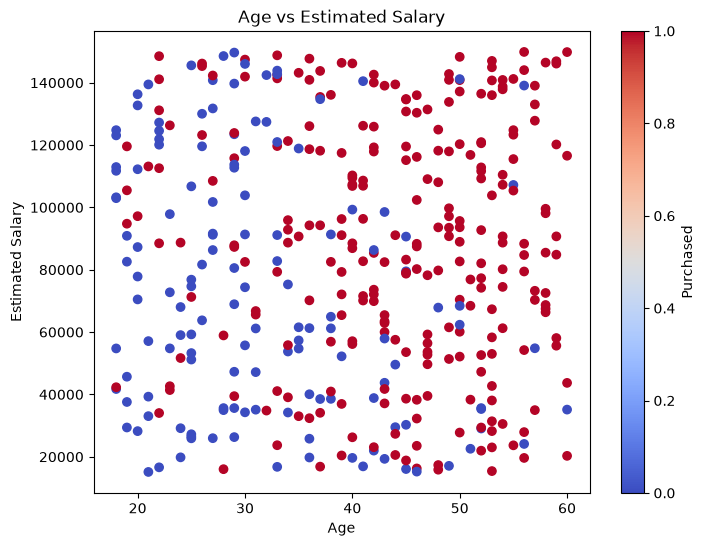

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Age"],
    df["EstimatedSalary"],
    c=df["Purchased"],
    cmap="coolwarm"
)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Age vs Estimated Salary")
plt.colorbar(label="Purchased")

plt.show()

In [ ]:
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Age  EstimatedSalary
0   41            71570
1   28            16015
2   25            76813
3   53            42712
4   55           115497

Target:
0    1
1    1
2    0
3    1
4    1
Name: Purchased, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (320, 2)
Testing data: (80, 2)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 0 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 1
 0 1 0 1 1 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7375


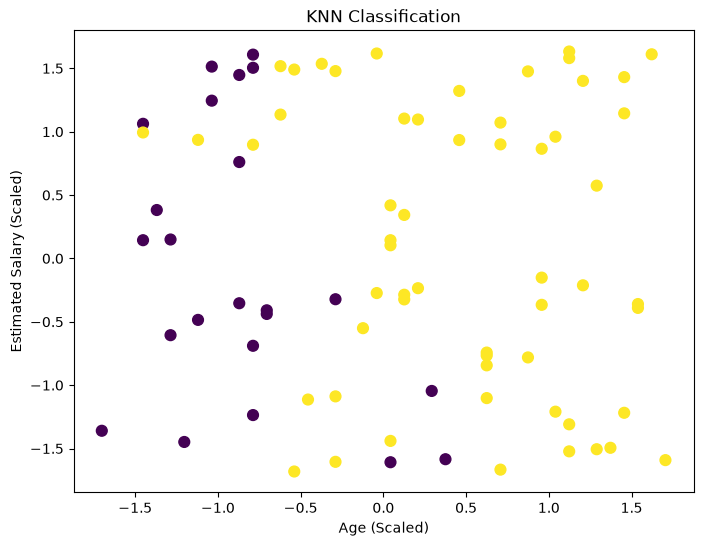

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred,
    cmap="viridis",
    s=60
)

plt.xlabel("Age (Scaled)")
plt.ylabel("Estimated Salary (Scaled)")
plt.title("KNN Classification")

plt.show()

In [ ]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print("K =", k, "Accuracy =", round(accuracy, 3))

K = 1 Accuracy = 0.725
K = 2 Accuracy = 0.713
K = 3 Accuracy = 0.775
K = 4 Accuracy = 0.762
K = 5 Accuracy = 0.738
K = 6 Accuracy = 0.75
K = 7 Accuracy = 0.75
K = 8 Accuracy = 0.762
K = 9 Accuracy = 0.738
K = 10 Accuracy = 0.75
K = 11 Accuracy = 0.775
K = 12 Accuracy = 0.8
K = 13 Accuracy = 0.775
K = 14 Accuracy = 0.8
K = 15 Accuracy = 0.775


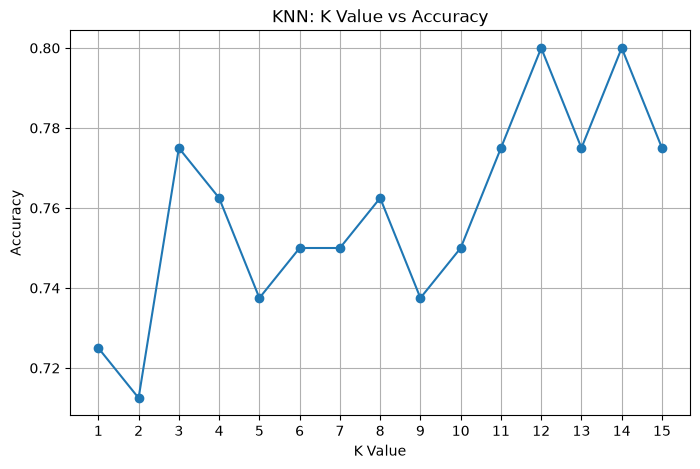

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")

plt.xticks(k_values)
plt.grid()

plt.show()

In [ ]:
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 12
Best Accuracy: 0.8
